In [2]:
from pathlib import Path
import json, csv
import pandas as pd
import matplotlib.pyplot as plt

base = Path('/home/csalt/Haider/DVLM/lvar/outputs/baseline_and_pooling_results')
files = {
    'Clevr':  base / 'clevr_pooling_predictions.jsonl',
    'M3Cot':  base / 'm3cot_pooling_predictions.jsonl',
    'ScienceQA':  base / 'scienceqa_pooling_predictions.jsonl',
}

In [3]:
def load_jsonl(path):
    with path.open() as f:
        return [json.loads(line) for line in f if line.strip()]

results = []
for dataset, path in files.items():
    data = load_jsonl(path)
    if not data:
        continue

    # pool where full_image is incorrect
    pool = [r for r in data if r.get("full_image_correct") is False]
    pool_size = len(pool)
    if pool_size == 0:
        for method in ["mean_pooled_correct", "max_pooled_correct", "region_mean_pooled_correct", "region_max_pooled_correct"]:
            results.append({"dataset": dataset, "method": method, "pool_size": 0, "correct_count": 0, "correct_pct": 0.0})
        continue

    method_fields = {
        "global_mean": "mean_pooled_correct",
        "global_max": "max_pooled_correct",
        "region_mean": "region_mean_pooled_correct",
        "region_max": "region_max_pooled_correct",
    }

    for label, field in method_fields.items():
        correct = sum(1 for r in pool if r.get(field) is True)
        results.append({
            "dataset": dataset,
            "method": label,
            "pool_size": pool_size,
            "correct_count": correct,
            "correct_pct": 100.0 * correct / pool_size,
        })

df = pd.DataFrame(results)
df_pivot = df.pivot(index="dataset", columns="method", values="correct_pct")
display(df)
display(df_pivot)

,dataset,method,pool_size,correct_count,correct_pct
0,Clevr,global_mean,346,89,25.722543
1,Clevr,global_max,346,84,24.277457
2,Clevr,region_mean,346,100,28.901734
3,Clevr,region_max,346,91,26.300578
4,M3Cot,global_mean,1321,242,18.319455
5,M3Cot,global_max,1321,239,18.092354
6,M3Cot,region_mean,1321,188,14.231643
7,M3Cot,region_max,1321,217,16.426949
8,ScienceQA,global_mean,466,100,21.459227
9,ScienceQA,global_max,466,95,20.386266


method,global_max,global_mean,region_max,region_mean
dataset,,,,
Clevr,24.277457,25.722543,26.300578,28.901734
M3Cot,18.092354,18.319455,16.426949,14.231643
ScienceQA,20.386266,21.459227,18.240343,17.381974


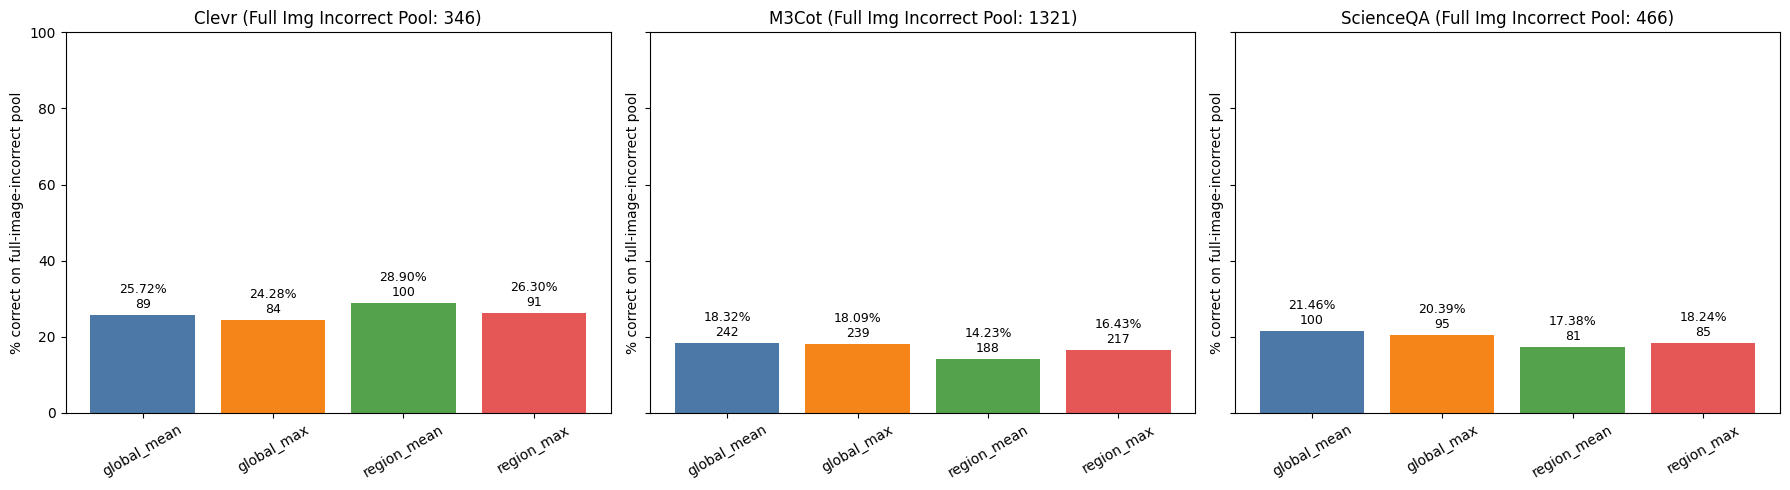

In [4]:
methods = ["global_mean", "global_max", "region_mean", "region_max"]
pool_sizes = df.groupby("dataset")["pool_size"].first().to_dict()
correct_counts = df.set_index(["dataset", "method"])["correct_count"].to_dict()

fig, axes = plt.subplots(1, len(df_pivot.index), figsize=(6 * len(df_pivot.index), 5), sharey=True)
if len(df_pivot.index) == 1:
    axes = [axes]
for ax, (dataset, row) in zip(axes, df_pivot.iterrows()):
    values = [row.get(m, 0.0) for m in methods]
    bars = ax.bar(methods, values, color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
    total_incorrect = pool_sizes.get(dataset, 0)
    ax.set_title(f"{dataset} (Full Img Incorrect Pool: {total_incorrect})")
    ax.set_ylim(0, 100)
    ax.set_ylabel("% correct on full-image-incorrect pool")
    ax.tick_params(axis="x", rotation=30)
    
    for bar, method, pct in zip(bars, methods, values):
        count = correct_counts.get((dataset, method), 0)
        ax.annotate(
            f"{pct:.2f}%\n{count}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

In [6]:
!pwd

/home/csalt/Haider/DVLM/lvar/results


In [14]:
import random
import textwrap
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Ensure the local lvar package is importable when running from the results folder.
_lvar_root = Path("/home/csalt/Haider/DVLM/lvar")
if str(_lvar_root) not in sys.path:
    sys.path.insert(0, str(_lvar_root))

from lvar.dataset import CLEVRCoGenTDataset, M3CoTDataset, ScienceQADataset


def _load_predictions(path):
    return load_jsonl(path)


def _build_example_index(dataset_name, prediction_rows):
    id_set = {str(row.get("example_id")) for row in prediction_rows}
    if dataset_name == "Clevr":
        dataset = CLEVRCoGenTDataset(partition="test")
    elif dataset_name == "M3Cot":
        dataset = M3CoTDataset(split="test")
    elif dataset_name == "ScienceQA":
        dataset = ScienceQADataset(split="test", require_image=True)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    index = {}
    for example in dataset:
        example_id = str(example.get("id"))
        if example_id in id_set:
            index[example_id] = example
        if len(index) >= len(id_set):
            break
    return index


def _pick_global_correct_full_wrong(rows):
    pool = [r for r in rows if r.get("full_image_correct") is False and (
        r.get("mean_pooled_correct") is True or r.get("max_pooled_correct") is True
    )]
    if not pool:
        return None, None
    row = random.choice(pool)
    candidates = []
    if row.get("mean_pooled_correct") is True:
        candidates.append("mean")
    if row.get("max_pooled_correct") is True:
        candidates.append("max")
    method = random.choice(candidates) if candidates else None
    return row, method


def _pick_region_correct_full_wrong(rows):
    pool = [r for r in rows if r.get("full_image_correct") is False and (
        r.get("region_mean_pooled_correct") is True or r.get("region_max_pooled_correct") is True
    )]
    if not pool:
        return None, None
    row = random.choice(pool)
    candidates = []
    if row.get("region_mean_pooled_correct") is True:
        candidates.append("mean")
    if row.get("region_max_pooled_correct") is True:
        candidates.append("max")
    method = random.choice(candidates) if candidates else None
    return row, method


def _pick_full_correct_global_wrong(rows):
    pool = [r for r in rows if r.get("full_image_correct") is True and (
        r.get("mean_pooled_correct") is False or r.get("max_pooled_correct") is False
    )]
    if not pool:
        return None, None
    row = random.choice(pool)
    candidates = []
    if row.get("mean_pooled_correct") is False:
        candidates.append("mean")
    if row.get("max_pooled_correct") is False:
        candidates.append("max")
    method = random.choice(candidates) if candidates else None
    return row, method


def _pick_full_correct_region_wrong(rows):
    pool = [r for r in rows if r.get("full_image_correct") is True and (
        r.get("region_mean_pooled_correct") is False or r.get("region_max_pooled_correct") is False
    )]
    if not pool:
        return None, None
    row = random.choice(pool)
    candidates = []
    if row.get("region_mean_pooled_correct") is False:
        candidates.append("mean")
    if row.get("region_max_pooled_correct") is False:
        candidates.append("max")
    method = random.choice(candidates) if candidates else None
    return row, method


def _wrap(text, width=60):
    if not text:
        return ""
    return "\n".join(textwrap.wrap(str(text), width=width))


def _render_panel(ax, example, title, question, answer):
    ax.axis("off")
    if example and example.get("image") is not None:
        ax.imshow(example["image"])
    ax.set_title(title, fontsize=11)
    ax.text(
        0.0,
        -0.05,
        _wrap(f"Q: {question}\nA: {answer}", width=55),
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
    )

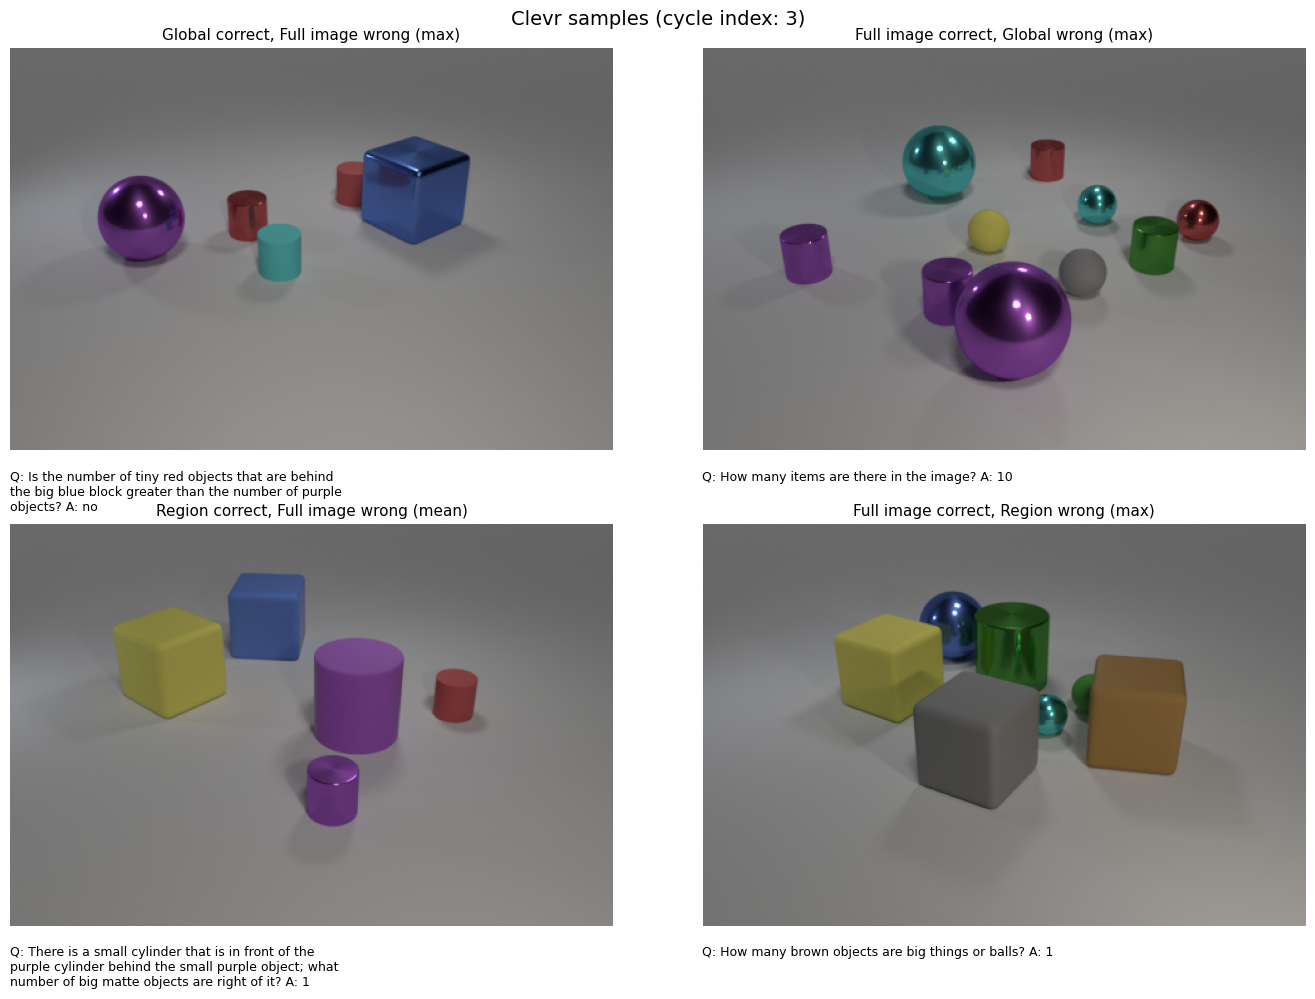

In [ ]:
# Cycle through datasets on each run.
_dataset_order = ["Clevr", "M3Cot", "ScienceQA"]
_cycle_idx = globals().get("_dataset_cycle_idx", 0)
dataset_name = _dataset_order[_cycle_idx % len(_dataset_order)]
_dataset_cycle_idx = _cycle_idx + 1

pred_rows = _load_predictions(files[dataset_name])
example_index = _build_example_index(dataset_name, pred_rows)

left_global, left_global_method = _pick_global_correct_full_wrong(pred_rows)
left_region, left_region_method = _pick_region_correct_full_wrong(pred_rows)
right_global, right_global_method = _pick_full_correct_global_wrong(pred_rows)
right_region, right_region_method = _pick_full_correct_region_wrong(pred_rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"{dataset_name} samples (cycle index: {_cycle_idx})", fontsize=14)

panels = [
    (0, 0, left_global, left_global_method, "Global correct, Full image wrong"),
    (1, 0, left_region, left_region_method, "Region correct, Full image wrong"),
    (0, 1, right_global, right_global_method, "Full image correct, Global wrong"),
    (1, 1, right_region, right_region_method, "Full image correct, Region wrong"),
]

for r, c, row, method, title in panels:
    ax = axes[r][c]
    if not row:
        ax.axis("off")
        ax.set_title(f"{title}\n(no sample found)", fontsize=11)
        continue
    example = example_index.get(str(row.get("example_id")))
    question = row.get("question")
    answer = row.get("gold_answer")
    method_label = ""
    if method:
        method_label = f" ({method})"
    _render_panel(ax, example, f"{title}{method_label}", question, answer)

plt.tight_layout()
plt.show()